## Minimal Points2Surf

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

start_dir = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (start_dir, *start_dir.parents) if (path / 'source').is_dir())
EXPERIMENT_DIR = PROJECT_ROOT / 'minimal_points2surf'
sys.path.insert(0, str(EXPERIMENT_DIR))

import pipeline
import visualization
importlib.reload(pipeline)
importlib.reload(visualization)

BUNNY_OBJ = PROJECT_ROOT / 'data' / 'box.obj'
DATASET_DIR = PROJECT_ROOT / 'datasets' / 'points2surf_bunny'
CHECKPOINT = PROJECT_ROOT / 'models' / 'p2s_vanilla_model_149.pth'

SEED = 42
NUM_SURFACE_POINTS = 20_000
NUM_QUERY_POINTS = 4_000
QUERY_OFFSETS = (0.02, 0.10)
VOLUME_PADDING = 0.15
NUM_MEDIAL_QUERIES = 500
NUM_MEDIAL_CANDIDATES = 30_000
MEDIAL_OFFSET = 0.03
MEDIAL_BAND_OFFSET = MEDIAL_OFFSET
USE_MEDIAL_BIASED_SAMPLING = False
MEDIAL_ADD_EPOCH = 0
NUM_EVAL_POINTS = 4_096
NUM_GT_MEDIAL_AXIS_POINTS = 1_000
NUM_BASELINE_MEDIAL_AXIS_POINTS = 0
GT_MEDIAL_AXIS_SURFACE_SAMPLES = 8_000
EVAL_EVERY = 5
PATCHES_PER_EPOCH = 1_000
BATCH_SIZE = 32

LOCAL_SAMPLE_SIZE = 300
GLOBAL_SAMPLE_SIZE = 1000

NUM_DATALOADER_WORKERS = 4
EPOCHS = 200
MEDIAL_EPOCHS = 200
MEDIAL_NUM_INTERIOR_POINTS = 16_384
MEDIAL_BATCH_SIZE = 512
MEDIAL_INTERIOR_MARGIN = 0.001
MEDIAL_SDF_GRID_RESOLUTION = 25
MEDIAL_SDF_GRID_BATCH_SIZE = 64
LR = 0.0001
MEDIAL_LR = 0.001
LR_DECAY_EPOCH = 50
EIKONAL_WEIGHT = 0
MEDIAL_WEIGHTS = {
    'maximality': 3000,
    'inscription': 500,
    'orthogonality': 10,
}

pipeline.seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


### Training data

In [2]:
mesh = pipeline.load_unit_mesh(BUNNY_OBJ)
points, query_points, query_sdf = pipeline.sample_training_data(
    mesh, NUM_SURFACE_POINTS, NUM_QUERY_POINTS, QUERY_OFFSETS, VOLUME_PADDING, SEED)
pipeline.write_training_dataset(DATASET_DIR, points, query_points, query_sdf)

num_volume_queries = NUM_QUERY_POINTS // 2
query_kinds = np.concatenate((
    np.zeros(num_volume_queries, dtype=np.int8),
    np.ones(len(query_points) - num_volume_queries, dtype=np.int8)))
print(f'{len(points):,} surface points | {len(query_points):,} SDF queries')

20,000 surface points | 4,000 SDF queries


### SDF model and training

In [3]:
dataset, sampler, loader = pipeline.make_training_loader(
    DATASET_DIR, PATCHES_PER_EPOCH, BATCH_SIZE, NUM_DATALOADER_WORKERS, SEED,
    points_per_patch=LOCAL_SAMPLE_SIZE, global_sample_size=GLOBAL_SAMPLE_SIZE,
    fixed_global_context=True, do_augmentation=False)

model, _ = pipeline.build_model(
    device, LR, points_per_patch=LOCAL_SAMPLE_SIZE,
    global_sample_size=GLOBAL_SAMPLE_SIZE)
pipeline.load_pretrained_weights(model, CHECKPOINT, invert_sign=True)
optimizer = pipeline.make_prediction_head_optimizer(model, LR)

evaluation = pipeline.make_evaluation_data(
    mesh, points, VOLUME_PADDING, NUM_EVAL_POINTS, NUM_BASELINE_MEDIAL_AXIS_POINTS,
    GT_MEDIAL_AXIS_SURFACE_SAMPLES, MEDIAL_OFFSET, SEED,
    global_sample_size=GLOBAL_SAMPLE_SIZE, fixed_global_context=True)

print(f'{len(sampler):,} patches per epoch | {len(loader):,} batches')
print(f'{sum(parameter.numel() for parameter in model.parameters()):,} parameters')
print(f'{sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad):,} trainable parameters')

getting information for 1 shapes
1,000 patches per epoch | 32 batches
6,167,814 parameters
296,322 trainable parameters


In [4]:
medial_sampler = lambda: pipeline.sample_medial_queries(
    mesh, VOLUME_PADDING, MEDIAL_OFFSET, MEDIAL_BAND_OFFSET,
    NUM_MEDIAL_CANDIDATES, NUM_MEDIAL_QUERIES, SEED + 2)

sdf_history, query_points, query_sdf, query_kinds = pipeline.train_model(
    model, optimizer, loader, dataset, DATASET_DIR,
    query_points, query_sdf, query_kinds, mesh, points, evaluation,
    device, SEED, EPOCHS, EVAL_EVERY, PATCHES_PER_EPOCH, BATCH_SIZE,
    NUM_DATALOADER_WORKERS, USE_MEDIAL_BIASED_SAMPLING, MEDIAL_ADD_EPOCH,
    medial_sampler, points_per_patch=LOCAL_SAMPLE_SIZE,
    global_sample_size=GLOBAL_SAMPLE_SIZE,
    lr_decay_epoch=LR_DECAY_EPOCH, eikonal_weight=EIKONAL_WEIGHT,
    restore_best=True, direct_magnitude_loss=True,
    query_conditioned_global=False, select_best_by_mae=True,
    fixed_global_context=True)
baseline_history = sdf_history

training:   0%|          | 0/200 [00:00<?, ?it/s]

### Medial field training

In [5]:
grid_bounds = mesh.bounds + np.array([
    [-VOLUME_PADDING] * 3, [VOLUME_PADDING] * 3])
medial_sdf_grid = pipeline.make_sdf_grid(
    model, points, evaluation, grid_bounds, device, SEED,
    MEDIAL_SDF_GRID_RESOLUTION, LOCAL_SAMPLE_SIZE,
    MEDIAL_SDF_GRID_BATCH_SIZE)

medial_bounds = mesh.bounds + np.array([
    [MEDIAL_INTERIOR_MARGIN] * 3, [-MEDIAL_INTERIOR_MARGIN] * 3])
medial_dataset, medial_loader = pipeline.make_medial_training_loader(
    medial_sdf_grid, medial_bounds, MEDIAL_NUM_INTERIOR_POINTS,
    MEDIAL_BATCH_SIZE, SEED + 3)

pipeline.add_query_medial_head(model)
medial_optimizer = pipeline.make_medial_optimizer(model, MEDIAL_LR)
medial_history = pipeline.train_medial_model(
    model, medial_optimizer, medial_loader, medial_sdf_grid,
    device, MEDIAL_EPOCHS, MEDIAL_WEIGHTS)
medial_metrics = pipeline.evaluate_box_medial_volume(
    model, mesh.bounds, device, seed=SEED + 4)
print(f'{len(medial_dataset):,} interior queries; {sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad):,} trainable medial parameters; M MAE: {medial_metrics["mae"]:.5f}')

training medial field:   0%|          | 0/200 [00:00<?, ?it/s]

16,384 interior queries; 4,481 trainable medial parameters; M MAE: 0.02522


### Results

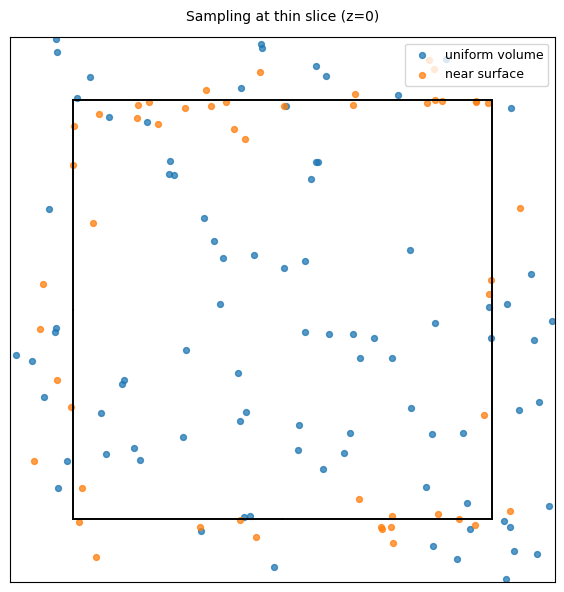

In [6]:
visualization.plot_active_sampling(
    mesh, query_points, query_kinds, VOLUME_PADDING,
    USE_MEDIAL_BIASED_SAMPLING)
plt.show()

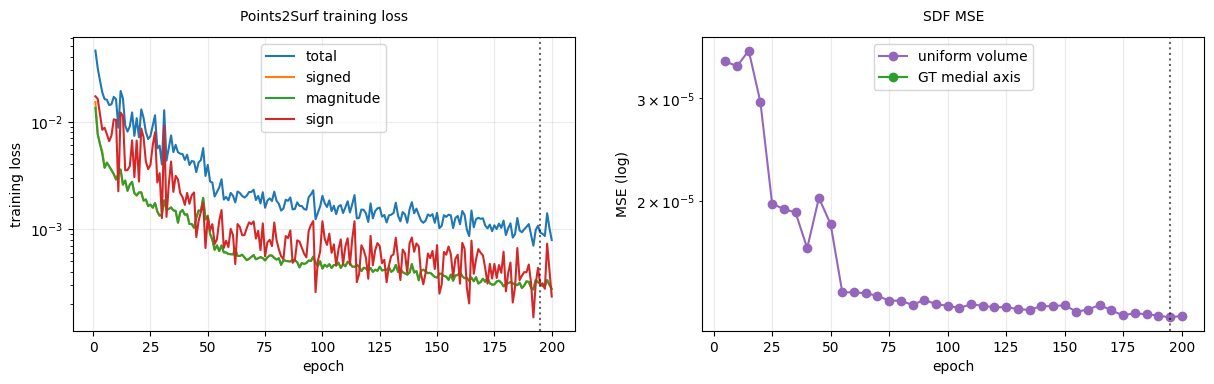

In [7]:
visualization.plot_training_history(sdf_history)
plt.show()

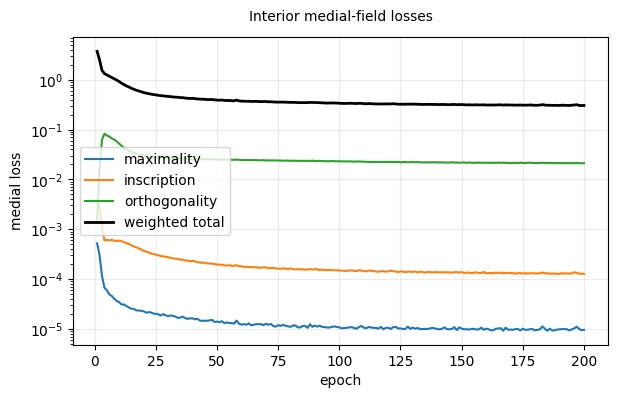

In [8]:
visualization.plot_medial_training_history(medial_history)
plt.show()

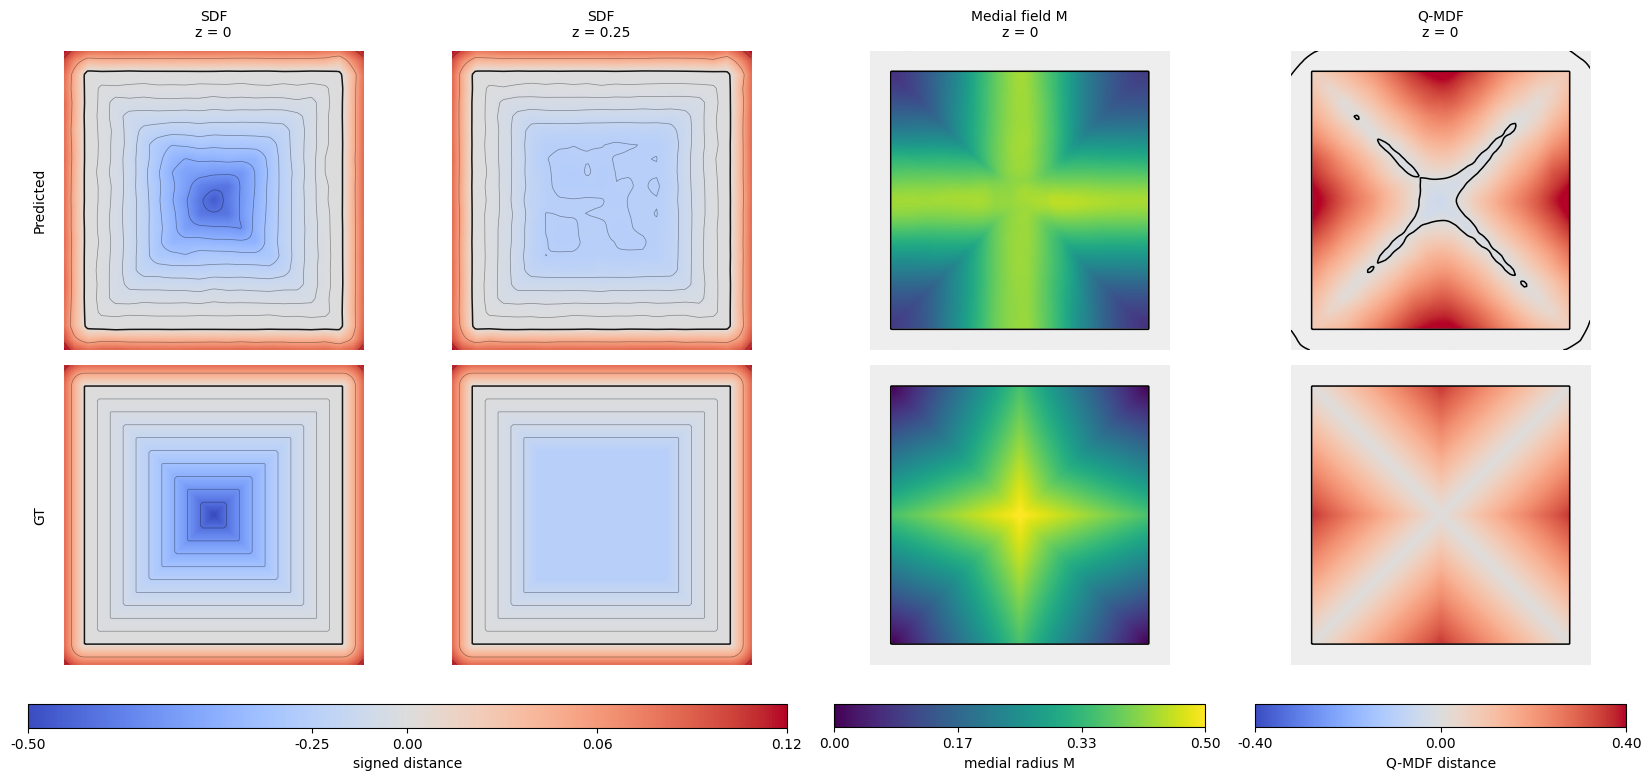

In [10]:
importlib.reload(pipeline)
importlib.reload(visualization)

predict_sdf = lambda queries: pipeline.predict_sdf_grid_queries(
    medial_sdf_grid, queries)
predict_medial = lambda queries: pipeline.predict_medial_queries(
    model, queries, device)
visualization.plot_sdf_slices(
    mesh, predict_sdf, predict_medial, slice_zs=(0.0, 0.25), resolution=128,
    isoline_spacing=0.05, interior_gamma=2.0)
plt.show()